# Notebook 08 - VW super-nodos

**Objetivo.** Formalizar la idea VW de super-nodos y separar equivalencias de
limitaciones reales.

**Pregunta guia.** Cuando VW reproduce al greedy miope y cuando pierde
informacion del posterior conjunto?

**Lectura esperada.** Sigue las tres comparaciones: completa, VW-A y VW-B;
despues mira los defectos.

**Formato.** Cada bloque sigue el mismo patron: contexto breve, parametros
(`n`, `B`, `G`, `p`, `u`), calculo reproducible y salida interpretada cerca del
codigo.

Este notebook responde tres preguntas sobre la propuesta de **VW super-nodos**:

1. ¿Qué es exactamente y reproduce al greedy actual?
2. ¿Qué pierde respecto al óptimo (lookahead gap, pregunta de Marmolejo sobre posteriores)?
3. ¿Cómo lo hacemos tractable en la práctica?

## Glosario rápido (lee esto antes que nada)

- **Pool $t$**: subconjunto de hasta $G$ individuos que probamos juntos.
- **Test aumentado**: el resultado es el conteo $r = |Z \cap t|$ — *cuántos* activos hay en el pool, no solo "conteo-no-cero/conteo-cero".
- **$Z$**: vector verdadero $\{0,1\}^n$ que dice quién está activo. Es desconocido; los tests nos dan información sobre él.
- **$S$ / $V$**: tras $k$ consultas, $S$ = todos los individuos ya tocados (unión de pools previos); $V$ = los que no hemos tocado.
- **Posterior marginal $\tilde p_i$**: $P(\text{individuo } i \text{ activo} \mid \text{tests})$. Una cifra por individuo.
- **Posterior conjunto $P(Z \mid \text{tests})$**: probabilidad sobre cada configuración completa $Z$. $2^n$ números.
- **All-clear de un pool $t$**: el evento "todos en $t$ son limpios". Si los individuos fueran independientes, $P(\text{all-clear}) = \prod_{i \in t}(1-\tilde p_i)$.
- **Pool conteo-no-cero**: el evento complementario, "al menos uno en $t$ activo". Bajo independencia, $P(\text{conteo-no-cero}) = 1 - \prod_{i \in t}(1-\tilde p_i)$. ⚠️ **Solo son complementos bajo independencia**: tras observar tests, $Z$ deja de ser independiente, así que el posterior conjunto $P(Z \mid \text{tests})$ no se factoriza y la fórmula del producto solo es una aproximación.
- **Utilidad** (en este notebook): $u(F, Z) = \sum_{i \text{ probado limpio al final}} u_i$ — la suma de los pesos $u_i$ de individuos que las consultas dejaron limpios.
- **Greedy miope**: política que en cada paso elige el pool con mejor valor *del paso actual*, ignorando pasos futuros.
- **DP óptimo**: política que considera las $B$ consultas a la vez y elige la mejor secuencia. Caro.
- **Lookahead gap**: utilidad esperada del DP − utilidad esperada del greedy. Mide cuánto se pierde por ser miope.
- **Super-nodo $w_T$**: idea de Marmolejo. Para cada subconjunto $T \subseteq S$ se crea un objeto que *resume* $T$ en tres números (peso $|T|$, prob, util) y se trata como un único candidato comprimido. Después se elige el siguiente pool combinando individuos sueltos de $V$ con a lo más un super-nodo $w_T$.
- **VW**: nombre que le pongo aquí al "problema de un paso" sobre $V \cup W$ — la decisión de cuál pool tirar a continuación cuando los candidatos son individuos en $V$ + super-nodos en $W$.


## Setup

Imports, path del repo y parametros graficos compartidos.

In [1]:
import os, sys
import math
import random
from itertools import combinations
import itertools as itt
import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.dirname(os.path.dirname(os.path.abspath(''))))

from augmented.core import (
    indices_from_mask, mask_from_indices, test_result,
)
from augmented.bayesian import (
    _poisson_binomial_pmf, bayesian_update_single_test,
)
from augmented.greedy import greedy_myopic_simulate
from augmented.solver import solve_optimal_dapts
from augmented.vw_demo import (
    _enumerate_full_pools, _enumerate_vw,
)
from augmented.vw_restrict import (
    restriction_experiment, adversarial_instance,
)
from augmented.vw_restrict_sweep import REGIMES, run_regime


## 2. Instancia de juguete (para ver todo a mano)

Usamos $n=6$ individuos, presupuesto $B=2$ consultas, pools de tamaño $G=3$.
Con $n=6$ podemos enumerar las $2^6=64$ configuraciones de $Z$ exactamente.

Hacemos *un* test sobre el pool $\{0,2,4\}$ con verdad $Z = \{2\}$ (solo el 2 está activo), entonces observamos $r_1 = 1$. Después de eso, $S = \{0,2,4\}$ y $V = \{1,3,5\}$.

In [2]:
n, G, B = 6, 3, 2
p_prior = [0.10, 0.15, 0.20, 0.08, 0.12, 0.25]
u = [4.0, 6.0, 3.0, 5.0, 7.0, 4.0]

pool1 = mask_from_indices([0, 2, 4])
z_true = mask_from_indices([2])
r1 = test_result(pool1, z_true)
p_post = bayesian_update_single_test(p_prior, pool1, r1, n)

S_idx = indices_from_mask(pool1, n)
V_idx = [i for i in range(n) if i not in S_idx]

print(f"prior     p = {p_prior}")
print(f"observado r1 = {r1} (en pool {S_idx})")
print(f"posterior p̃ = {[round(x, 3) for x in p_post]}")
print(f"S = {S_idx},  V = {V_idx}")


prior     p = [0.1, 0.15, 0.2, 0.08, 0.12, 0.25]
observado r1 = 1 (en pool [0, 2, 4])
posterior p̃ = [0.223, 0.15, 0.503, 0.08, 0.274, 0.25]
S = [0, 2, 4],  V = [1, 3, 5]


## 3. Las tres maneras de elegir el siguiente pool

Las tres calculan un **score** para cada pool candidato $t$ y eligen el de mayor score. Lo que cambia es **cómo descomponen el cálculo**.

### 3.1 Completa (gold standard)

Trata $t$ como una sola lista. Para cada $t \subseteq [n]$ con $|t| \le G$:
$$
\text{score}_{\text{Completa}}(t) \;=\; \Big(\sum_{i \in t} u_i\Big) \cdot \prod_{i \in t}(1-\tilde p_i)
$$
Es la "utilidad esperada del pool si todos salen limpios". Esta es la versión que el greedy miope estándar ya calcula. Caro porque enumera $\binom{n}{1}+\dots+\binom{n}{G}$ pools.

### 3.2 VW-A y VW-B (super-nodos)

**Idea de Marmolejo:** separar $t = T \cup U$, donde $T \subseteq S$ (gente ya tocada) y $U \subseteq V$ (gente nueva). Ahora $T$ no se trata como individuos sueltos sino como **un solo objeto comprimido** $w_T$ con solo tres números: $|T|$, $\pi_T$, $\mu_T = \sum_{i\in T} u_i$. El score es:
$$
\text{score}_{\text{VW}}(T, U) \;=\; \big(\mu_T + \sum_{i \in U} u_i\big)\;\cdot\;\pi_T\;\cdot\;\prod_{i \in U}(1-\tilde p_i)
$$

La única diferencia entre **VW-A** y **VW-B** es cómo se elige $\pi_T$:

| variante | $\pi_T$ | interpretación |
|---|---|---|
| **VW-A** | $\prod_{i\in T}(1-\tilde p_i)$ | "todos en $T$ limpios" |
| **VW-B** | $1 - \prod_{i\in T}(1-\tilde p_i)$ | "al menos uno en $T$ conteo-no-cero" |

**Claim:** VW-A da exactamente el mismo score que Completa para todo $t$ (re-formulación, no algoritmo nuevo). VW-B optimiza algo distinto y elige peor.

In [3]:
# Verificación numérica con UN pool específico para que se vea la equivalencia.
t = (1, 3, 4)   # un pool candidato concreto
T = tuple(i for i in t if i in S_idx)   # parte ya tocada
U = tuple(i for i in t if i in V_idx)   # parte nueva
print(f"pool t = {t}    →    T = {T} (en S),   U = {U} (en V)")

util_t = sum(u[i] for i in t)
prob_t = math.prod(1 - p_post[i] for i in t)
score_completa = util_t * prob_t

mu_T   = sum(u[i] for i in T) if T else 0.0
pi_T_A = math.prod(1 - p_post[i] for i in T) if T else 1.0
pi_T_B = (1 - pi_T_A) if T else 1.0
util_U = sum(u[i] for i in U)
prob_U = math.prod(1 - p_post[i] for i in U) if U else 1.0
score_VW_A = (mu_T + util_U) * pi_T_A * prob_U
score_VW_B = (mu_T + util_U) * pi_T_B * prob_U

print(f"\nscore_Completa = (Σu_t) · ∏(1-p̃)_t           = {util_t:.3f} · {prob_t:.3f} = {score_completa:.4f}")
print(f"score_VW_A    = (μ_T + Σu_U) · π_T · ∏(1-p̃)_U = ({mu_T:.1f} + {util_U:.1f}) · {pi_T_A:.3f} · {prob_U:.3f} = {score_VW_A:.4f}")
print(f"score_VW_B    = (μ_T + Σu_U) · (1-π_T_A) · ∏(1-p̃)_U                        = {score_VW_B:.4f}")
print(f"\nVW-A == Completa? {abs(score_VW_A - score_completa) < 1e-9}")
print(f"VW-B == Completa? {abs(score_VW_B - score_completa) < 1e-9}")

print("\nAhora la enumeración completa: ¿qué pool elige cada uno?")
pool_full, val_full = _enumerate_full_pools(S_idx, V_idx, p_post, u, G)
pool_A,    val_A    = _enumerate_vw(S_idx, V_idx, p_post, u, G, "all_clear")
pool_B,    val_B    = _enumerate_vw(S_idx, V_idx, p_post, u, G, "or_event")
print(f"  Completa : pool {indices_from_mask(pool_full)}  score={val_full:.4f}")
print(f"  VW-A     : pool {indices_from_mask(pool_A)}  score={val_A:.4f}  →  ¿mismo pool y score que Completa? {abs(val_A-val_full)<1e-9}")
print(f"  VW-B     : pool {indices_from_mask(pool_B)}  score={val_B:.4f}  →  ¿mismo pool y score que Completa? {abs(val_B-val_full)<1e-9}")


pool t = (1, 3, 4)    →    T = (4,) (en S),   U = (1, 3) (en V)

score_Completa = (Σu_t) · ∏(1-p̃)_t           = 18.000 · 0.568 = 10.2176
score_VW_A    = (μ_T + Σu_U) · π_T · ∏(1-p̃)_U = (7.0 + 11.0) · 0.726 · 0.782 = 10.2176
score_VW_B    = (μ_T + Σu_U) · (1-π_T_A) · ∏(1-p̃)_U                        = 3.8584

VW-A == Completa? True
VW-B == Completa? False

Ahora la enumeración completa: ¿qué pool elige cada uno?
  Completa : pool [1, 3, 4]  score=10.2176
  VW-A     : pool [1, 3, 4]  score=10.2176  →  ¿mismo pool y score que Completa? True
  VW-B     : pool [0, 2, 4]  score=10.0737  →  ¿mismo pool y score que Completa? False


## 4. Defecto 1 — el "escalar" pierde información

### ¿Qué quiere decir "escalar"?

Cuando VW reemplaza el subconjunto $T$ por su super-nodo $w_T$, lo que guarda son solo **tres números**:

$$
w_T \;=\; \big(\;|T|,\; \pi_T,\; \mu_T\;\big)
$$

Por ejemplo, si $T = \{0, 2, 4\}$ con $\tilde p = (0.22, 0.50, 0.27)$ y $u = (4, 3, 7)$:

- $|T| = 3$
- $\pi_T = (1-0.22)(1-0.50)(1-0.27) = 0.285$
- $\mu_T = 4 + 3 + 7 = 14$

Esos tres números son la "compresión escalar" de $T$. Todo lo demás —la distribución conjunta de quién entre $T$ está activo, las correlaciones inducidas por tests anteriores, la distribución del conteo $r$ que veríamos si probáramos $T$ otra vez— se descarta.

### El defecto

**Dos subconjuntos $T$ distintos pueden tener el mismo escalar pero comportarse muy distinto en pasos futuros.** Cuando el dynamic greedy mira más allá de un paso, lo que importa es la distribución del conteo $r$ de cada candidato, no solo su all-clear-prob.

Ejemplo concreto:
- $T_1 = \{a\}$ con $p_a = 0.5$. Aquí $r \in \{0,1\}$.
- $T_2 = \{b, c\}$ con $p_b = p_c = 1 - 1/\sqrt{2} \approx 0.293$. Aquí $r \in \{0,1,2\}$.

Ambos tienen $\pi_T = \prod(1-p) = 0.5$ (igual all-clear) y la misma OR-prob = 0.5 — o sea, **escalar idéntico**. Pero las distribuciones del conteo $r$ son distintas: $T_1$ es Bernoulli con dos valores; $T_2$ tiene tres valores.

### ¿Por qué entropía?

Para poner un *número* a "qué tan distintas son las dos PMFs" usamos Shannon entropy $H(r) = -\sum_r \Pr(r)\log_2 \Pr(r)$. Es solo un medidor — si $H$ es más alta, la distribución carga más información (más spread / más posibles valores con peso). Aquí $H(T_1) = 1.00$ bits y $H(T_2) = 1.33$ bits, así que $T_2$ carga **0.33 bits más** de información sobre $Z$ que $T_1$. La entropía no entra en la formulación VW; solo nos sirve para demostrar que el escalar pierde información.

In [4]:
p_a  = 0.5
p_bc = 1 - 0.5 ** 0.5
pmf1 = _poisson_binomial_pmf([p_a])
pmf2 = _poisson_binomial_pmf([p_bc, p_bc])
H1 = -sum(pi * math.log2(pi) for pi in pmf1 if pi > 0)
H2 = -sum(pi * math.log2(pi) for pi in pmf2 if pi > 0)

print(f"T1 = {{a}},   PMF de r: {[round(x,3) for x in pmf1]}   entropía H = {H1:.3f} bits")
print(f"T2 = {{b,c}}, PMF de r: {[round(x,3) for x in pmf2]}   entropía H = {H2:.3f} bits")
print(f"Diferencia de info: H(T2) - H(T1) = {H2-H1:.3f} bits")


T1 = {a},   PMF de r: [0.5, 0.5]   entropía H = 1.000 bits
T2 = {b,c}, PMF de r: [0.5, 0.414, 0.086]   entropía H = 1.331 bits
Diferencia de info: H(T2) - H(T1) = 0.331 bits


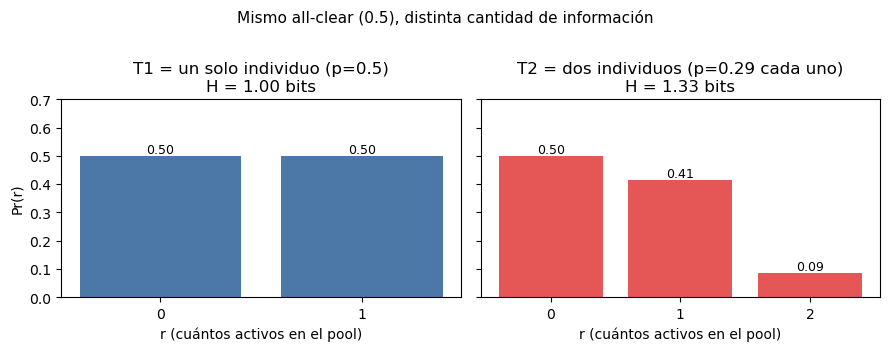

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(9, 3.4), sharey=True)
ax[0].bar([0, 1], pmf1, color='#4C78A8')
for x, v in enumerate(pmf1):
    ax[0].text(x, v+0.01, f"{v:.2f}", ha='center', fontsize=9)
ax[0].set_xticks([0, 1]); ax[0].set_ylim(0, 0.7)
ax[0].set_xlabel("r (cuántos activos en el pool)")
ax[0].set_ylabel("Pr(r)")
ax[0].set_title(f"T1 = un solo individuo (p=0.5)\nH = {H1:.2f} bits")

ax[1].bar([0, 1, 2], pmf2, color='#E45756')
for x, v in enumerate(pmf2):
    ax[1].text(x, v+0.01, f"{v:.2f}", ha='center', fontsize=9)
ax[1].set_xticks([0, 1, 2]); ax[1].set_ylim(0, 0.7)
ax[1].set_xlabel("r (cuántos activos en el pool)")
ax[1].set_title(f"T2 = dos individuos (p=0.29 cada uno)\nH = {H2:.2f} bits")

fig.suptitle("Mismo all-clear (0.5), distinta cantidad de información",
             fontsize=11, y=1.02)
fig.tight_layout(); plt.show()


## 5. Defecto 2 — el *lookahead gap*

**¿Qué es el lookahead gap?**
- *Greedy miope*: en cada paso elige el pool de mayor valor *inmediato*. Es como jugar ajedrez moviendo solo la pieza que da más valor en este turno, sin mirar adelante.
- *DP óptimo*: enumera todas las secuencias posibles de $B$ pasos y elige la mejor. Caro pero óptimo.
- **Lookahead gap = utilidad(DP) − utilidad(greedy)**. Mide cuánto perdemos por ser miopes.

VW escalar es matemáticamente equivalente al greedy miope (Defecto 1), entonces VW *no cierra el gap por sí solo*. Lo medimos:

In [6]:
def greedy_true(p_prior, u, B, G, n):
    q = [1 - pi for pi in p_prior]
    total = 0.0
    for z in range(1 << n):
        w = 1.0
        for i in range(n):
            w *= p_prior[i] if (z >> i) & 1 else q[i]
        _, _, util_z = greedy_myopic_simulate(p_prior, u, B, G, z)
        total += w * util_z
    return total

print(f"{'B':>3} {'greedy(true)':>14} {'DP optimum':>14} {'gap':>10}")
print(f"{'-'*3} {'-'*14} {'-'*14} {'-'*10}")
for B_eval in (2, 3):
    g = greedy_true(p_prior, u, B_eval, G, n)
    o, _ = solve_optimal_dapts(p_prior, u, B_eval, G)
    print(f"{B_eval:>3} {g:>14.4f} {o:>14.4f} {o-g:>+10.4f}")

print("\nLectura: con B=2 perdemos 0.14 utils; con B=3 perdemos 1.96 utils.")
print("El gap *crece* con B porque cada paso miope se equivoca un poquito.")


  B   greedy(true)     DP optimum        gap
--- -------------- -------------- ----------
  2        18.4414        18.5817    +0.1403


  3        20.4740        22.4339    +1.9599

Lectura: con B=2 perdemos 0.14 utils; con B=3 perdemos 1.96 utils.
El gap *crece* con B porque cada paso miope se equivoca un poquito.


## 6. Defecto 3 — joint vs marginales (pregunta de Marmolejo)

Marmolejo señala: la heurística dynamic-greedy supone

$$P(t \subseteq [n] \text{ es conteo-no-cero} \mid \text{tests}) \approx 1 - \prod_{i \in t}(1-\tilde p_i)$$

(es decir, asume que los individuos son independientes después de los tests). **Pero no son independientes**: los tests inducen correlaciones.

**Contraejemplo de Marmolejo.** Si $t' \subsetneq t$ y observamos $t'$ conteo-no-cero, entonces $t$ es necesariamente conteo-no-cero (todo superset de un pool conteo-no-cero es conteo-no-cero). O sea $P(t \text{ pos} \mid t' \text{ pos}) = 1$. Pero $1-\prod_{i\in t}(1-\tilde p_i)$ puede ser bastante menor que 1.

**Lo que vamos a hacer.** Tomamos $n=6$ (chico, podemos enumerar las $2^n=64$ configuraciones). Observamos un par de tests, calculamos el *posterior conjunto* exacto $P(Z\mid\text{tests})$, sacamos las marginales $\tilde p_i$, y para *cada* subconjunto $t$ no vacío comparamos:

- **Verdad**: $P(t \text{ conteo-no-cero} \mid \text{tests}) = \sum_{Z : Z \cap t \ne \emptyset} P(Z \mid \text{tests})$.
- **Aproximación marginal**: $1 - \prod_{i\in t}(1-\tilde p_i)$.

In [7]:
def joint_posterior(n, p_prior, tests):
    """Posterior exacto P(Z|tests) sobre las 2^n configuraciones de Z.

    tests: lista de (pool_idx_tuple, r_observed).
    Returns: dict {Z_int: prob}.
    """
    raw = {}
    for Z in range(1 << n):
        # peso del prior P(Z)
        w = 1.0
        for i in range(n):
            w *= p_prior[i] if (Z >> i) & 1 else (1.0 - p_prior[i])
        # likelihood (test es determinista dado Z): P(r_obs | Z, t) = 1 si match, 0 si no
        for pool_idx, r_obs in tests:
            r_true = sum(1 for i in pool_idx if (Z >> i) & 1)
            if r_true != r_obs:
                w = 0.0
                break
        raw[Z] = w
    Z_total = sum(raw.values())
    return {k: v / Z_total for k, v in raw.items()} if Z_total > 0 else None

def marginals(joint, n):
    return [sum(p for Z, p in joint.items() if (Z >> i) & 1) for i in range(n)]

def true_pos_prob(joint, t_idx):
    """P(pool t tiene >=1 activo | tests)."""
    t_mask = sum(1 << i for i in t_idx)
    return sum(p for Z, p in joint.items() if (Z & t_mask) != 0)

# Historia de tests: dos pools, ambos vieron r=1 activo
tests = [((0, 2, 4), 1), ((1, 3, 5), 1)]
joint = joint_posterior(n, p_prior, tests)
p_til = marginals(joint, n)

print(f"Después de los 2 tests:")
print(f"  marginales tilde_p = {[round(x, 3) for x in p_til]}")
print(f"  núm de Z con prob > 0: {sum(1 for p in joint.values() if p > 1e-12)} de 64")


Después de los 2 tests:
  marginales tilde_p = [0.223, 0.296, 0.503, 0.146, 0.274, 0.559]
  núm de Z con prob > 0: 9 de 64


In [8]:
# Para cada t ⊆ [n] no vacío, calcula verdad y aproximación
rows = []
for size in range(1, n + 1):
    for t in itt.combinations(range(n), size):
        verdad = true_pos_prob(joint, t)
        aprox  = 1 - math.prod(1 - p_til[i] for i in t)
        rows.append((t, size, verdad, aprox))

# Top-5 desviaciones para inspección
worst = sorted(rows, key=lambda r: -abs(r[2] - r[3]))[:5]
print("Top-5 desviaciones |verdad − aprox|:")
print(f"{'t':<22} {'|t|':>4} {'verdad':>8} {'aprox':>8} {'Δ':>9}")
for t, sz, v, a in worst:
    print(f"  {str(t):<20} {sz:>4} {v:>8.3f} {a:>8.3f} {v-a:>+9.3f}")

# Casos especiales: pools enteros que coinciden con un test pasado
print("\nCasos donde 'verdad' = 1 (pool contiene todo un test conteo-no-cero):")
for t, sz, v, a in rows:
    if abs(v - 1.0) < 1e-9 and sz <= 4:
        print(f"  t={t}: verdad=1.000, aprox={a:.3f}  →  perdemos {1-a:.3f} de prob")


Top-5 desviaciones |verdad − aprox|:
t                       |t|   verdad    aprox         Δ
  (0, 2, 4)               3    1.000    0.720    +0.280
  (1, 3, 5)               3    1.000    0.734    +0.266
  (0, 2, 3, 4)            4    1.000    0.760    +0.240
  (0, 1, 3, 5)            4    1.000    0.794    +0.206
  (0, 1, 2, 4)            4    1.000    0.802    +0.198

Casos donde 'verdad' = 1 (pool contiene todo un test conteo-no-cero):
  t=(0, 2, 4): verdad=1.000, aprox=0.720  →  perdemos 0.280 de prob
  t=(1, 3, 5): verdad=1.000, aprox=0.734  →  perdemos 0.266 de prob
  t=(0, 1, 2, 4): verdad=1.000, aprox=0.802  →  perdemos 0.198 de prob
  t=(0, 1, 3, 5): verdad=1.000, aprox=0.794  →  perdemos 0.206 de prob
  t=(0, 2, 3, 4): verdad=1.000, aprox=0.760  →  perdemos 0.240 de prob
  t=(0, 2, 4, 5): verdad=1.000, aprox=0.876  →  perdemos 0.124 de prob
  t=(1, 2, 3, 5): verdad=1.000, aprox=0.868  →  perdemos 0.132 de prob
  t=(1, 3, 4, 5): verdad=1.000, aprox=0.807  →  perdemos 0.193 de

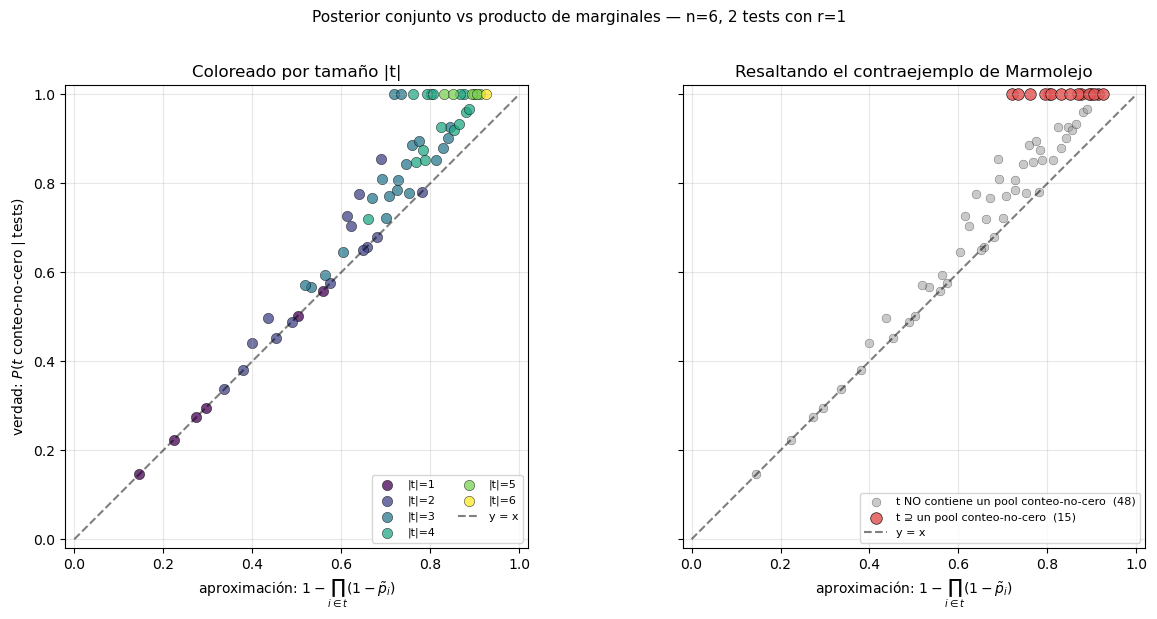

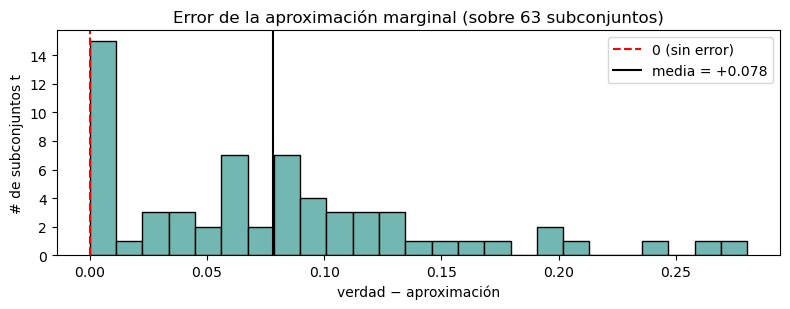

In [9]:
# Scatter en dos paneles: izquierda coloreado por |t|, derecha
# resaltando los t que contienen completo algún pool conteo-no-cero observado
# (esos son justamente los casos del contraejemplo de Marmolejo).
nonzero_count_pools = [set(p) for p, r in tests if r >= 1]

def contains_nonzero_count_pool(t):
    return any(set(t) >= p for p in nonzero_count_pools)

fig, axes = plt.subplots(1, 2, figsize=(13, 6), sharey=True, sharex=True)

# Panel izquierdo
cmap = plt.cm.viridis
for size in range(1, n + 1):
    pts = [(r[3], r[2]) for r in rows if r[1] == size]
    if not pts: continue
    xs, ys = zip(*pts)
    axes[0].scatter(xs, ys, c=[cmap((size-1)/(n-1))], label=f"|t|={size}",
                    alpha=0.75, s=55, edgecolor='black', linewidth=0.4)
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.5, label='y = x')
axes[0].set_title("Coloreado por tamaño |t|")
axes[0].set_xlabel(r"aproximación: $1 - \prod_{i\in t}(1-\tilde p_i)$")
axes[0].set_ylabel(r"verdad: $P(t\ \text{conteo-no-cero}\mid\text{tests})$")
axes[0].legend(loc='lower right', fontsize=8, ncol=2)
axes[0].grid(alpha=0.3); axes[0].set_aspect('equal')

# Panel derecho: contiene pool conteo-no-cero vs no
group_yes = [(r[3], r[2]) for r in rows if contains_nonzero_count_pool(r[0])]
group_no  = [(r[3], r[2]) for r in rows if not contains_nonzero_count_pool(r[0])]
if group_no:
    xs, ys = zip(*group_no)
    axes[1].scatter(xs, ys, c='#9D9D9D', alpha=0.55, s=40, edgecolor='black',
                    linewidth=0.3, label=f't NO contiene un pool conteo-no-cero  ({len(group_no)})')
if group_yes:
    xs, ys = zip(*group_yes)
    axes[1].scatter(xs, ys, c='#E45756', alpha=0.85, s=70, edgecolor='black',
                    linewidth=0.5, label=f't ⊇ un pool conteo-no-cero  ({len(group_yes)})')
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.5, label='y = x')
axes[1].set_title("Resaltando el contraejemplo de Marmolejo")
axes[1].set_xlabel(r"aproximación: $1 - \prod_{i\in t}(1-\tilde p_i)$")
axes[1].legend(loc='lower right', fontsize=8)
axes[1].grid(alpha=0.3); axes[1].set_aspect('equal')

axes[0].set_xlim(-0.02, 1.02); axes[0].set_ylim(-0.02, 1.02)

fig.suptitle("Posterior conjunto vs producto de marginales — n=6, 2 tests con r=1",
             fontsize=11, y=1.02)
fig.tight_layout(); plt.show()

# Distribución del error
errs = np.array([r[2] - r[3] for r in rows])
fig2, ax2 = plt.subplots(figsize=(8, 3.2))
ax2.hist(errs, bins=25, color='#72B7B2', edgecolor='black')
ax2.axvline(0, color='red', ls='--', label='0 (sin error)')
ax2.axvline(errs.mean(), color='black', ls='-', label=f'media = {errs.mean():+.3f}')
ax2.set_xlabel("verdad − aproximación")
ax2.set_ylabel("# de subconjuntos t")
ax2.set_title(f"Error de la aproximación marginal (sobre {len(rows)} subconjuntos)")
ax2.legend(); fig2.tight_layout(); plt.show()


 k_tests   mean|err|   max|err|
       1      0.0106     0.2851
       2      0.0296     0.2894
       3      0.0127     0.2889


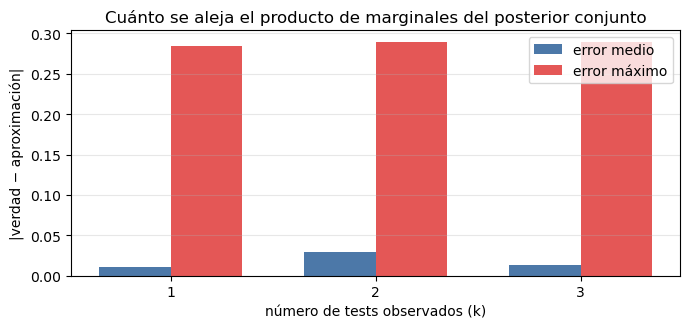

In [10]:
# Sweep: ¿el error empeora con más tests? (más tests = más correlaciones inducidas)
random.seed(7)
sweep = []
for k_tests in range(1, 4):
    err_abs = []
    for trial in range(15):
        rng = random.Random(100*k_tests + trial)
        Z_true_int = sum(1 << i for i in range(n) if rng.random() < p_prior[i])
        tests_t = []
        for _ in range(k_tests):
            pool = tuple(sorted(rng.sample(range(n), G)))
            r_obs = sum(1 for i in pool if (Z_true_int >> i) & 1)
            tests_t.append((pool, r_obs))
        j = joint_posterior(n, p_prior, tests_t)
        if j is None: continue
        p_t = marginals(j, n)
        for size in range(1, n+1):
            for t in itt.combinations(range(n), size):
                v = true_pos_prob(j, t)
                a = 1 - math.prod(1 - p_t[i] for i in t)
                err_abs.append(abs(v - a))
    sweep.append((k_tests, np.mean(err_abs), np.max(err_abs)))

print(f"{'k_tests':>8} {'mean|err|':>11} {'max|err|':>10}")
for k, m, mx in sweep:
    print(f"{k:>8} {m:>11.4f} {mx:>10.4f}")

ks = [r[0] for r in sweep]
fig, ax = plt.subplots(figsize=(7, 3.4))
w = 0.35
ax.bar([k-w/2 for k in ks], [r[1] for r in sweep], w, color='#4C78A8', label='error medio')
ax.bar([k+w/2 for k in ks], [r[2] for r in sweep], w, color='#E45756', label='error máximo')
ax.set_xticks(ks); ax.set_xlabel("número de tests observados (k)")
ax.set_ylabel("|verdad − aproximación|")
ax.set_title("Cuánto se aleja el producto de marginales del posterior conjunto")
ax.legend(); ax.grid(axis='y', alpha=0.3)
fig.tight_layout(); plt.show()


In [11]:
# Respuesta directa a "Is it usually similar?" — números, no narrativa.
errs_abs = np.array([abs(r[2] - r[3]) for r in rows])

print("Sobre los", len(rows), "subconjuntos t no vacíos (instancia n=6, 2 tests con r=1):")
print(f"  mediana   |error|     = {np.median(errs_abs):.3f}")
print(f"  percentil 75          = {np.percentile(errs_abs, 75):.3f}")
print(f"  percentil 90          = {np.percentile(errs_abs, 90):.3f}")
print(f"  percentil 99          = {np.percentile(errs_abs, 99):.3f}")
print(f"  máximo                = {errs_abs.max():.3f}")
print(f"  fracción con |error| < 0.05 = {(errs_abs < 0.05).mean():.0%}")
print(f"  fracción con |error| < 0.10 = {(errs_abs < 0.10).mean():.0%}")

# Restringido a los t con score MIOPE alto (los que el greedy
# realmente consideraría escoger). Score = (Σu) · ∏(1-p̃).
def myopic_score(t):
    return sum(u[i] for i in t) * math.prod(1 - p_til[i] for i in t)

scored = sorted(rows, key=lambda r: -myopic_score(r[0]))
top25 = scored[: max(1, len(scored)//4)]
errs_top = np.array([abs(r[2] - r[3]) for r in top25])
print(f"\nRestringido al top-25% por score miope ({len(top25)} subconjuntos):")
print(f"  mediana   |error| = {np.median(errs_top):.3f}")
print(f"  percentil 90      = {np.percentile(errs_top, 90):.3f}")
print(f"  máximo            = {errs_top.max():.3f}")
print(f"  fracción con |error| < 0.05 = {(errs_top < 0.05).mean():.0%}")

# Restringido a los t que CONTIENEN un pool conteo-no-cero (Marmolejo)
errs_struct = np.array([abs(r[2] - r[3]) for r in rows if contains_nonzero_count_pool(r[0])])
print(f"\nRestringido a t que ⊇ algún pool conteo-no-cero ({len(errs_struct)} subconjuntos):")
print(f"  mediana   |error| = {np.median(errs_struct):.3f}")
print(f"  máximo            = {errs_struct.max():.3f}")


Sobre los 63 subconjuntos t no vacíos (instancia n=6, 2 tests con r=1):
  mediana   |error|     = 0.070
  percentil 75          = 0.109
  percentil 90          = 0.168
  percentil 99          = 0.271
  máximo                = 0.280
  fracción con |error| < 0.05 = 37%
  fracción con |error| < 0.10 = 70%

Restringido al top-25% por score miope (15 subconjuntos):
  mediana   |error| = 0.043
  percentil 90      = 0.108
  máximo            = 0.240
  fracción con |error| < 0.05 = 60%

Restringido a t que ⊇ algún pool conteo-no-cero (15 subconjuntos):
  mediana   |error| = 0.150
  máximo            = 0.280


### Respuesta directa a "Is it usually similar?"

**Sí, *en promedio* son razonablemente similares** — en esta instancia (n=6, 2 tests con r=1):

- mediana del error absoluto ≈ **0.07**
- 70% de los $t$ tienen error < 0.10
- el error máximo en TODA la población es ~**0.28** (no se va a 1.0 aquí porque ambos tests vieron exactamente un activo, lo cual ya determina mucho)

**Pero la magnitud del peor caso depende del régimen.** En instancias con prevalencia muy baja y pools grandes que igual salen conteo-no-ceros, el gap del peor caso puede acercarse a 1 (verdad = 1, aproximación << 1). El sweep registro que el error MÁXIMO no decrece con más tests — al contrario, sube — porque cada test conteo-no-cero nuevo añade un $t \supseteq \text{pool conteo-no-cero}$ al conjunto problemático.

**Sub-conjuntos que sí importan:**

- Top-25% de $t$ por score miope (los que el greedy realmente consideraría escoger): mediana 0.04, 60% con error < 0.05. Aproximación razonable *donde la usas*.
- $t$ que contienen completo un pool conteo-no-cero observado: mediana 0.15, máximo 0.28. La aproximación SIEMPRE subestima estos casos.

### Veredicto

- **Operativamente:** la heurística de marginales no es desastrosa para greedy miope típico — error mediano y de los pools competitivos son moderados.
- **Para una garantía teórica:** problema. Una consulta de submodularidad adaptativa necesita control **uniforme** sobre $t$, y el peor caso *crece* con el número de tests. Promedio bajo ≠ garantía.

## 7. Q3 — restricción de $W$ a top-L (heurísticas)

$W$ tiene $2^{|S|}$ candidatos $T$; enumerarlos todos es caro. Probamos **6 heurísticas** que ranquean los $T$, y medimos $L_{\min}$ = el menor $L$ tal que el top-$L$ contiene al $T$ óptimo.

- `self`: $(\sum u_T)\cdot\prod(1-\tilde p_T)$ — el valor del pool $T$ solo.
- `prob`: $\prod(1-\tilde p_T)$.
- `util`: $\sum u_T$.
- `ent_λ`: `self` $+\,\lambda\cdot H(r_T)$ — versión "informativa": le suma a `self` la entropía del conteo de $T$, con la idea de que un $T$ con $H(r_T)$ alta es más informativo cuando se consulta. (Es la *segunda* aparición de entropía: ahora como ingrediente de heurística, no como medidor.) Spoiler: empíricamente no le gana a `partner`.
- `partner`: $(\sum u_T + u^*)\cdot\prod(1-\tilde p_T)\cdot p^*$ — tiene en cuenta el mejor "partner" en $V$ que cabría en el presupuesto restante.
- `random`: baseline.

In [12]:
res = restriction_experiment(p_post, S_idx, V_idx, u, G, rand_seed=0)
print(f"|W| = {res['W_size']} candidatos T")
for k in sorted([k for k in res if k.startswith("L_min_")]):
    name = k.replace("L_min_", "")
    print(f"  {name:<10}  L_min = {res[k]:>3}  ({res[k]/res['W_size']:.0%} de |W|)")


|W| = 7 candidatos T
  ent_1       L_min =   2  (29% de |W|)
  ent_25      L_min =   6  (86% de |W|)
  ent_5       L_min =   5  (71% de |W|)
  partner     L_min =   1  (14% de |W|)
  prob        L_min =   2  (29% de |W|)
  rand        L_min =   5  (71% de |W|)
  self        L_min =   2  (29% de |W|)
  util        L_min =   4  (57% de |W|)


## 8. Caso adversarial — donde `self` falla feo

Construimos a mano un caso donde un super-nodo $T$ "atractivo" (alta utilidad) es trampa: combinado con $V$, el pool conjunto baja mucho su prob de all-clear. Aquí `self` paga por su miopía y `partner` gana porque sí mira el costo de oportunidad del presupuesto.

In [13]:
p_adv, S_adv, V_adv, u_adv, G_adv = adversarial_instance()
print(f"S = {S_adv},  V = {V_adv},  G = {G_adv}")
print(f"p = {p_adv}")
print(f"u = {u_adv}")
res_adv = restriction_experiment(p_adv, S_adv, V_adv, u_adv, G_adv, rand_seed=0)
print(f"\n|W|={res_adv['W_size']}  val_full={res_adv['val_full']:.3f}  val_empty={res_adv['val_empty']:.3f}")
for k in sorted([k for k in res_adv if k.startswith("L_min_")]):
    name = k.replace("L_min_", "")
    print(f"  {name:<10}  L_min = {res_adv[k]:>3}  ({res_adv[k]/res_adv['W_size']:.0%})")


S = [0, 1, 2, 3],  V = [4, 5],  G = 4
p = [0.01, 0.01, 0.6, 0.05, 0.05, 0.5]
u = [1.0, 1.0, 100.0, 50.0, 60.0, 80.0]

|W|=15  val_full=99.275  val_empty=66.500
  ent_1       L_min =   8  (53%)
  ent_25      L_min =  12  (80%)
  ent_5       L_min =   8  (53%)
  partner     L_min =   2  (13%)
  prob        L_min =   4  (27%)
  rand        L_min =  15  (100%)
  self        L_min =   8  (53%)
  util        L_min =  12  (80%)


## 9. Sweep de regímenes — ¿`partner` aguanta?

Corremos $K=20$ trials por régimen sobre 6 regímenes (baseline, alta prevalencia, $n$ grande, historia profunda, prevalencia bimodal, utilidad heterogénea). Reportamos `mean / max` de $L_{\min}$.

In [14]:
print(f"{'regime':<40}  {'|W|':>6}  {'partner':>9}  {'self':>9}  {'ent_1':>9}")
print(f"{'-'*40}  {'-'*6}  {'-'*9}  {'-'*9}  {'-'*9}")

regime_data = []
for spec in REGIMES:
    name, n_, G_, k_, pd, ud = spec
    out = run_regime(name, n_, G_, k_, pd, ud, K=20, base_seed=42)
    if out is None: continue
    regime_data.append(out)
    m, x = out["means"], out["maxes"]
    print(f"{name:<40}  {out['mean_W']:>6.1f}  "
          f"{m['L_min_partner']:>4.1f}/{x['L_min_partner']:<3}  "
          f"{m['L_min_self']:>4.1f}/{x['L_min_self']:<3}  "
          f"{m['L_min_ent_1']:>4.1f}/{x['L_min_ent_1']:<3}")


regime                                       |W|    partner       self      ent_1
----------------------------------------  ------  ---------  ---------  ---------
baseline (n=10,G=4,2-step,low p)            79.7   1.6/13    4.3/21    7.0/38 
high prevalence (n=10,G=4,p~U[0.4,0.7])     79.7   2.8/14    0.7/2     0.9/3  


larger n (n=15,G=5,2-step,low p)           278.3   1.1/4    12.7/132  18.2/184
deep history (n=10,G=3,3-step)              62.9   1.1/3     3.8/18    4.4/23 
bimodal p (10/90 mix of 0.05/0.7)           79.7   1.0/1     8.4/35    9.8/47 


outlier utility (u_0=50, rest U[1,10])      79.7   1.4/12    2.4/13    2.5/14 


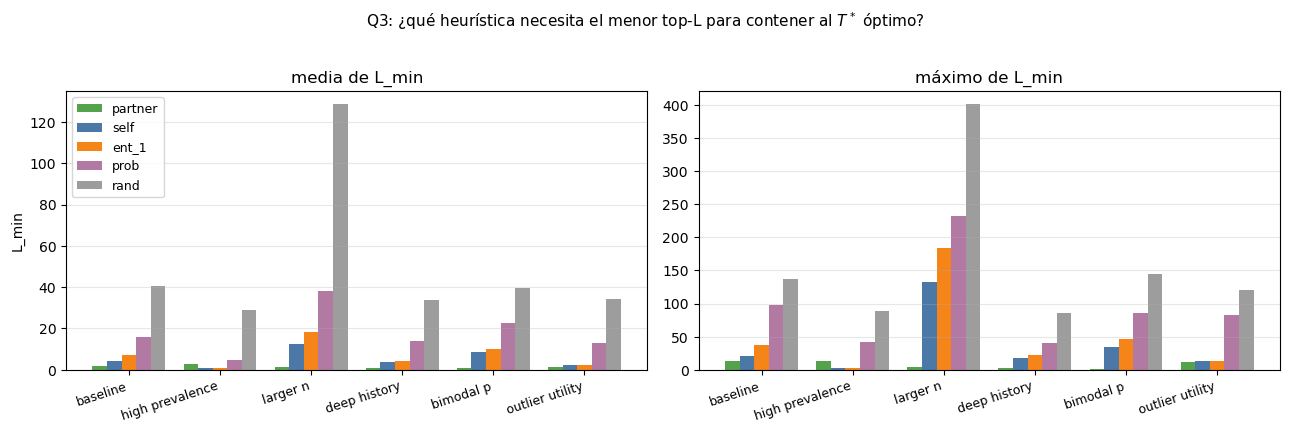

In [15]:
# Dos paneles: media y máximo, para que las barras no se aplasten
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
heur = [("partner", "#54A24B"),
        ("self",    "#4C78A8"),
        ("ent_1",   "#F58518"),
        ("prob",    "#B279A2"),
        ("rand",    "#9D9D9D")]
labels = [r["name"].split("(")[0].strip() for r in regime_data]
xs = np.arange(len(labels))
w = 0.16

for ax, key, title in [(axes[0], 'means', 'media de L_min'),
                       (axes[1], 'maxes', 'máximo de L_min')]:
    for i, (name, color) in enumerate(heur):
        vals = [r[key][f"L_min_{name}"] for r in regime_data]
        ax.bar(xs + (i - 2)*w, vals, w, label=name, color=color)
    ax.set_xticks(xs)
    ax.set_xticklabels(labels, rotation=18, ha='right', fontsize=9)
    ax.set_title(title)
    ax.grid(axis='y', alpha=0.3)
    if ax is axes[0]:
        ax.set_ylabel("L_min")
        ax.legend(loc='upper left', fontsize=9)

fig.suptitle(r"Q3: ¿qué heurística necesita el menor top-L para contener al $T^*$ óptimo?",
             y=1.02, fontsize=11)
fig.tight_layout(); plt.show()


## 10. Conclusiones

| Hallazgo | Implicación |
|---|---|
| VW-A ($\prod(1-\tilde p)$) reproduce el greedy miope **exacto**. | VW escalar es una *re-formulación*, no un algoritmo nuevo. |
| Un escalar no captura el **count PMF** (Defecto 1). | Pasos futuros tratan distinto a $T$'s con misma all-clear pero distinta info. |
| **Lookahead gap** crece con $B$ (0.14 → 1.96). | Greedy miope (= VW escalar) deja utilidad en la mesa. |
| **Joint vs marginales** (Marmolejo): mediana ~0.07, 70% con error < 0.10. Pero el **máximo** crece con el número de tests conteo-no-ceros observados. | La heurística marginal es razonable en uso operativo (greedy miope) pero el peor caso no está acotado uniformemente. |
| `partner` heuristic comprime $\|W\|=2^{\|S\|}$ a $L_{\min}\approx 1$–3 en *todos* los regímenes. | Hace tractable la enumeración de super-nodos en la práctica. |

**Lo que queda abierto:** demostrar (o refutar) submodularidad adaptativa de $g_h(T,U)$ con observación de conteo. Eso es lo que decidiría si VW + `partner` da una garantía global $(1 - e^{-\alpha})$.